In [1]:
import pandas as pd
import numpy as numpy 
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("combined_baseball_data.csv", low_memory= False)

dict = {
      'Fastball':         '4-Seam',
    'FourSeamFastBall': '4-Seam',
    'FourSeamFastball': '4-Seam',
    'Slider':           'Slider',
    'Curveball':        'Curveball',
    'ChangeUp':         'Changeup',
    'Cutter':           'Cutter',
    'Sinker':           'Sinker',
    'Sweeper':          'Sweeper',
}

df["PitchType"] = df["TaggedPitchType"].map(dict)
df["swing"] = df["PitchCall"].isin(['StrikeSwinging', 'FoulBallNotFieldable', 'FoulBallFieldable','InPlay'])
df["whiff"] = df['PitchCall'] == 'StrikeSwinging'

FOCUS = ['4-seam', 'Slider', 'Curveball', 'Changeup', 'Cutter', 'Sinker', 'Sweeper']
FEATURES = ['RelSpeed', 'InducedVertBreak', 'HorzBreak', 'SpinRate', 'VertApprAngle', 'Extension', 'PlateLocSide', 'PlateLocHeight']

df_swings = df[df['swing'] & df['PitchType'].isin(FOCUS)].dropna(subset=FEATURES).copy()
print(df_swings.groupby('PitchType')[['whiff']].agg(['size', 'sum', 'mean']).round(3))


          whiff            
           size  sum   mean
PitchType                  
Changeup    889  262  0.295
Curveball   882  291  0.330
Cutter      387  111  0.287
Sinker      459   87  0.190
Slider     1861  615  0.330
Sweeper     207   69  0.333


In [3]:
agg = (df[df['PitchType'].isin(FOCUS)]
      .groupby('PitchType')
      .agg(
          Pitches = ('PitchCall', 'size'),
          Swings = ('swing', 'sum'),
          Whiffs = ('whiff', 'sum'),
      )
      .assign(**{
          'Swing%' : lambda x: (x.Swings / x.Pitches * 100).round(1),
          'Whiff%' : lambda x: (x.Whiffs / x.Swings * 100).round(1),
          'SwStr%' : lambda x: (x.Whiffs / x.Pitches * 100).round(1),
      })
      )
print(agg.sort_values('Whiff%', ascending =False).to_string())


           Pitches  Swings  Whiffs  Swing%  Whiff%  SwStr%
PitchType                                                 
Sweeper        710     207      69    29.2    33.3     9.7
Slider        4866    1862     616    38.3    33.1    12.7
Curveball     2565     882     291    34.4    33.0    11.3
Changeup      1914     890     262    46.5    29.4    13.7
Cutter         847     387     111    45.7    28.7    13.1
Sinker        1013     459      87    45.3    19.0     8.6


In [4]:
df['PitchType'] = df['TaggedPitchType'].map(dict)
df['swing'] = df['PitchCall'].isin(['StrikeSwinging', 'FoulBallNotFieldable', 'FoulBallFieldable', 'InPlay'])
df['whiff'] = df['PitchCall'] == 'StrikeSwinging'

FOCUS = ['4-Seam', 'Slider', 'Curveball', 'Changeup', 'Cutter', 'Sinker']
FEATURES = ['RelSpeed', 'InducedVertBreak', 'HorzBreak', 'SpinRate',
            'VertApprAngle', 'Extension', 'PlateLocSide', 'PlateLocHeight']

df_swings = df[df['swing'] & df['PitchType'].isin(FOCUS)].dropna(subset=FEATURES).copy()
print(df_swings['PitchType'].value_counts())
print(df_swings.shape)

PitchType
4-Seam       7164
Slider       1861
Changeup      889
Curveball     882
Sinker        459
Cutter        387
Name: count, dtype: int64
(11642, 170)


In [7]:
from sklearn.metrics import roc_auc_score

models = {}
scalers = {}
results = {}

for pitch in FOCUS: 
    print(f"starting {pitch}")
    sub = df_swings[df_swings['PitchType']== pitch].copy()
    X = sub[FEATURES].values
    Y = sub['whiff'].values

    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_sc, Y)

    auc = roc_auc_score(Y, model.predict_proba(X_sc)[:, 1])

    models[pitch] = model
    scalers[pitch] = scaler
    results[pitch] = pd.Series(model.coef_[0], index=FEATURES).rename('coef')

    print(f"{pitch:12s} n={len(Y): 5d} whiff%={Y.mean()*100: .1f} AUC={auc: .3f}")

starting 4-Seam
4-Seam       n= 7164 whiff%= 21.6 AUC= 0.633
starting Slider
Slider       n= 1861 whiff%= 33.0 AUC= 0.743
starting Curveball
Curveball    n=  882 whiff%= 33.0 AUC= 0.694
starting Changeup
Changeup     n=  889 whiff%= 29.5 AUC= 0.692
starting Cutter
Cutter       n=  387 whiff%= 28.7 AUC= 0.632
starting Sinker
Sinker       n=  459 whiff%= 19.0 AUC= 0.608


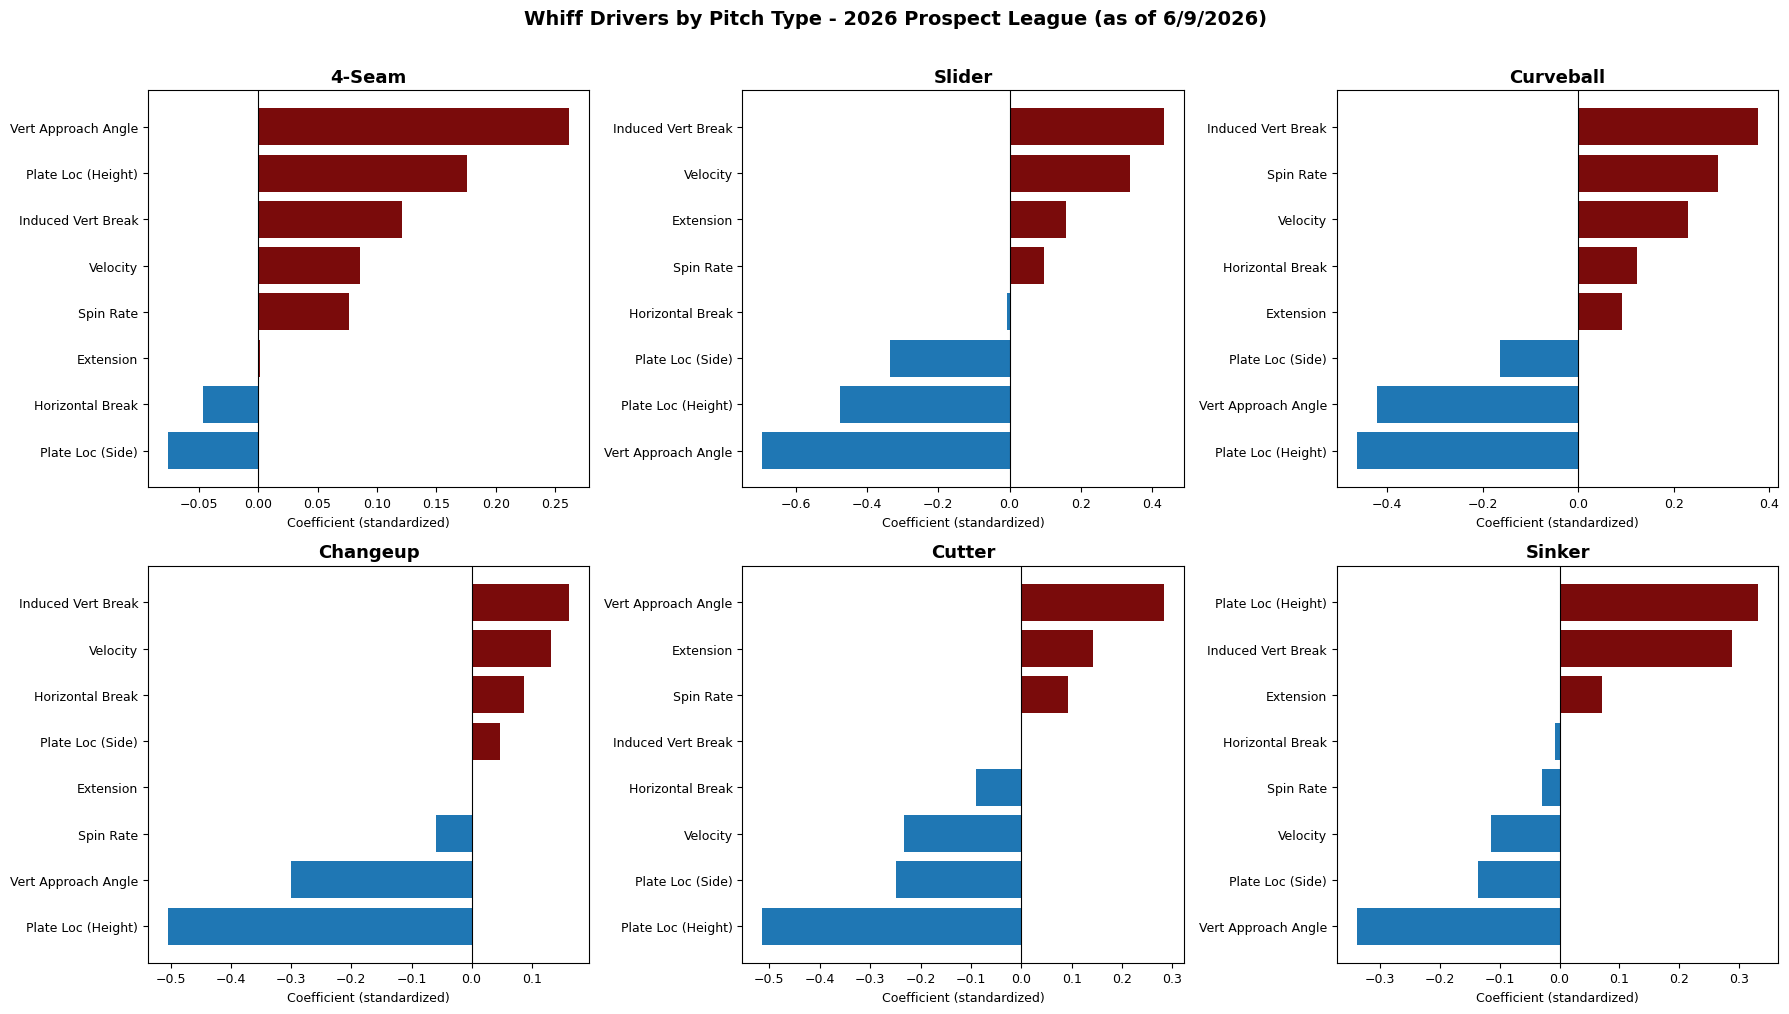

In [9]:
fig, axes = plt.subplots(2, 3, figsize = (18, 10))
axes = axes.flatten()

FEATURE_LABELS = {
    'RelSpeed':         'Velocity',
    'InducedVertBreak': 'Induced Vert Break',
    'HorzBreak':        'Horizontal Break',
    'SpinRate':         'Spin Rate',
    'VertApprAngle':    'Vert Approach Angle',
    'Extension':        'Extension',
    'PlateLocSide':     'Plate Loc (Side)',
    'PlateLocHeight':   'Plate Loc (Height)',
}

for ax, pitch in zip(axes, FOCUS):
    coefs = results[pitch].sort_values()
    colors =["#7A0B0B" if c > 0 else '#1f77b4' for c in coefs]
    labels = [FEATURE_LABELS[f] for f in coefs.index]

    ax.barh(labels, coefs.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(pitch, fontsize=13, fontweight= 'bold')
    ax.set_xlabel('Coefficient (standardized)', fontsize=9)
    ax.set_xlabel('Coefficient (standardized)', fontsize=9)
    ax.tick_params(labelsize=9)

fig.suptitle('Whiff Drivers by Pitch Type - 2026 Prospect League (as of 6/9/2026)', fontsize=14, fontweight = 'bold', y=1.01)
plt.tight_layout()
plt.savefig('whiff_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
summary_rows =[]
for pitch in FOCUS:
    coefs = results[pitch]
    top2 = coefs.nlargest(2).index.tolist()
    bot2 = coefs.nsmallest(2).index.tolist()

    summary_rows.append({
        'Pitch Type':      pitch,
        'Top whiff driver':   FEATURE_LABELS[top2[0]],
        '2nd whiff driver':   FEATURE_LABELS[top2[1]],
        'Top suppressor':     FEATURE_LABELS[bot2[0]],
        '2nd suppressor':     FEATURE_LABELS[bot2[1]],
    })
summary = pd.DataFrame(summary_rows).set_index('Pitch Type')
print(summary.to_string())

               Top whiff driver    2nd whiff driver       Top suppressor       2nd suppressor
Pitch Type                                                                                   
4-Seam      Vert Approach Angle  Plate Loc (Height)     Plate Loc (Side)     Horizontal Break
Slider       Induced Vert Break            Velocity  Vert Approach Angle   Plate Loc (Height)
Curveball    Induced Vert Break           Spin Rate   Plate Loc (Height)  Vert Approach Angle
Changeup     Induced Vert Break            Velocity   Plate Loc (Height)  Vert Approach Angle
Cutter      Vert Approach Angle           Extension   Plate Loc (Height)     Plate Loc (Side)
Sinker       Plate Loc (Height)  Induced Vert Break  Vert Approach Angle     Plate Loc (Side)


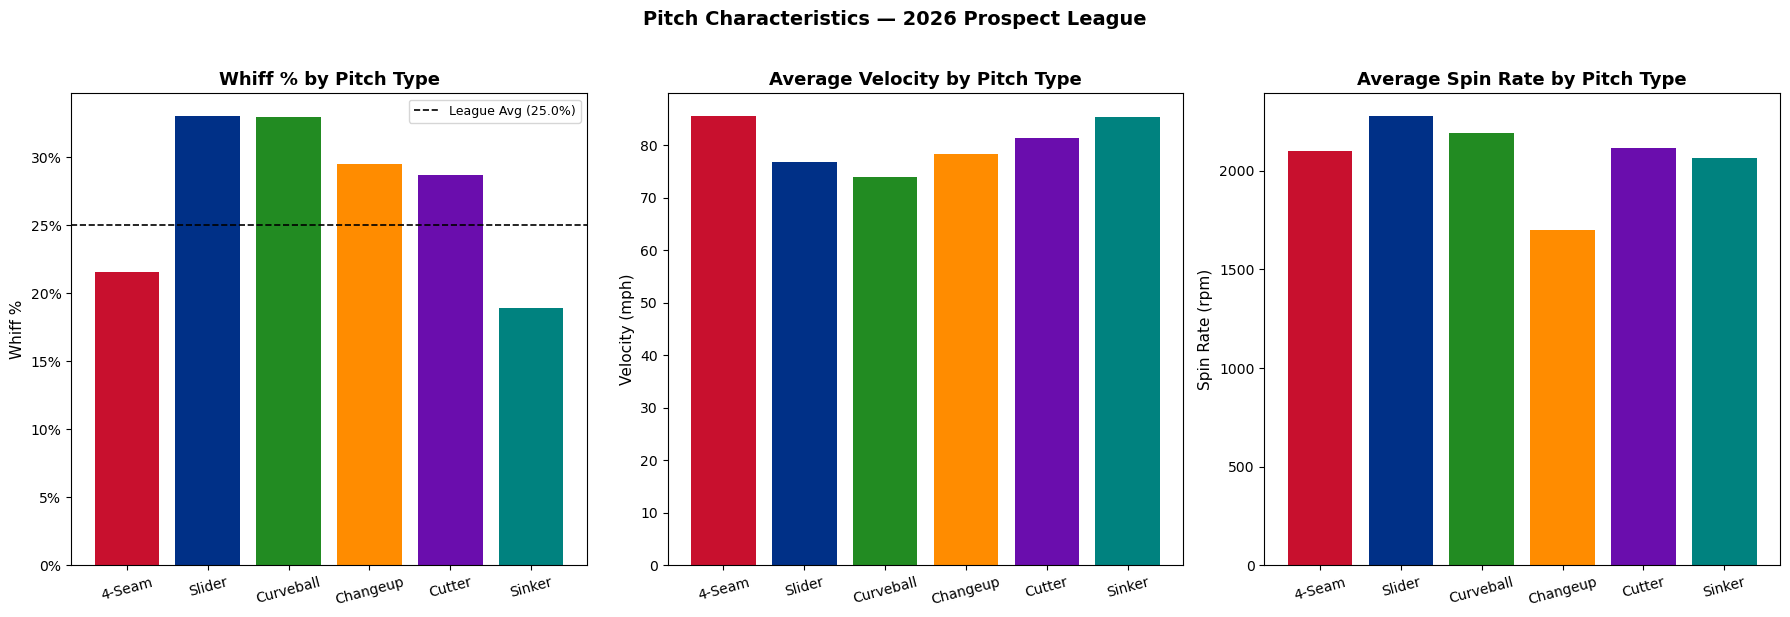

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Data ---
summary = df_swings.groupby('PitchType').agg(
    whiff_rate=('whiff', 'mean'),
    avg_velo=('RelSpeed', 'mean'),
    avg_spin=('SpinRate', 'mean'),
    n=('whiff', 'size')
).loc[FOCUS].reset_index()

league_whiff = df_swings['whiff'].mean() * 100
colors = ['#C8102E','#003087','#228B22','#FF8C00','#6A0DAD','#00827F']

# --- Plot 1: Whiff% by pitch type ---
axes[0].bar(summary['PitchType'], summary['whiff_rate'] * 100, color=colors)
axes[0].axhline(league_whiff, color='black', linestyle='--', linewidth=1.2, label=f'League Avg ({league_whiff:.1f}%)')
axes[0].set_title('Whiff % by Pitch Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Whiff %', fontsize=11)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

# --- Plot 2: Avg Velocity by pitch type ---
axes[1].bar(summary['PitchType'], summary['avg_velo'], color=colors)
axes[1].set_title('Average Velocity by Pitch Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Velocity (mph)', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

# --- Plot 3: Avg Spin Rate by pitch type ---
axes[2].bar(summary['PitchType'], summary['avg_spin'], color=colors)
axes[2].set_title('Average Spin Rate by Pitch Type', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Spin Rate (rpm)', fontsize=11)
axes[2].tick_params(axis='x', rotation=15)

fig.suptitle('Pitch Characteristics — 2026 Prospect League', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pitch_characteristics.png', dpi=150, bbox_inches='tight')
plt.show()